In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

In [3]:
# 데이터 로드
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# 데이터 로드 (경로는 본인의 환경에 맞게 수정하세요)
file_path = '/content/drive/MyDrive/2013~2025 가을 쾌적도 분류 라벨링 결과.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')

In [13]:
# 결측치 제거: Temp 컬럼의 NaN 값 처리
df = df.dropna(subset=['Temp'])

In [14]:
# 사용자 정의 쾌적도 라벨 생성
df['comfortable'] = (
    (df['Temp'] >= 14) & (df['Temp'] <= 22) &
    (df['PM25'] <= 35)
).astype(int)

In [7]:
# 특성(X)과 타겟(y) 설정
feature_cols = ['Temp', 'PM25']
target_col = 'comfortable'
X = df[feature_cols].copy()
y = df[target_col].copy()

In [8]:
# 데이터 분할 (층화 추출 적용)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. 교차 검증을 통한 K값 탐색 및 데이터 출력
k_range = range(1, 21)
print(f"{'K':<5} | {'CV Mean Acc':<15} | {'Fitting Status (Tentative)'}")
print("-" * 50)

for k in k_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    # 5-겹 교차 검증 수행
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()

    # 임시 상태 확인 (CV 점수 기준)
    status = "Searching..."
    print(f"{k:<5} | {cv_mean:<15.4f} | {status}")

# 최적의 K 결정
best_k = 4 # 이전 분석 결과인 4를 기준으로 진행하거나 위 루프에서 max값을 추출합니다.

# 2. 최종 모델 확정 및 상세 진단
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])
final_model.fit(X_train, y_train)

# 각 세트별 정확도 계산
train_acc = final_model.score(X_train, y_train)
test_acc = final_model.score(X_test, y_test)
cv_final_mean = cross_val_score(final_model, X_train, y_train, cv=5).mean()

print("\n" + "="*50)
print(f" [ 최종 모델 진단 결과 (K={best_k}) ]")
print("="*50)
print(f"- Train Accuracy      : {train_acc:.4f}")
print(f"- CV Mean Accuracy    : {cv_final_mean:.4f}")
print(f"- Test Accuracy       : {test_acc:.4f}")
print(f"- Train-Test Gap      : {abs(train_acc - test_acc):.4f}")
print("-" * 50)

# 3. 과적합/과소적합 판단 로직
if train_acc < 0.70:
    result = "과소적합 (Underfitting): 모델이 데이터의 패턴을 전혀 학습하지 못했습니다. K를 줄이거나 특성을 추가하세요."
elif (train_acc - test_acc) > 0.05:
    result = "과대적합 (Overfitting): 훈련 데이터에만 너무 익숙해져 있습니다. K를 늘리거나 데이터를 더 확보하세요."
else:
    result = "이상적 상태 (Ideal): 모델이 일반화가 잘 되어 새로운 데이터도 잘 예측할 것으로 보입니다."

print(f"진단 결과: {result}")

K     | CV Mean Acc     | Fitting Status (Tentative)
--------------------------------------------------
1     | 0.9905          | Searching...
2     | 0.9884          | Searching...
3     | 0.9884          | Searching...
4     | 0.9884          | Searching...
5     | 0.9831          | Searching...
6     | 0.9788          | Searching...
7     | 0.9788          | Searching...
8     | 0.9831          | Searching...
9     | 0.9788          | Searching...
10    | 0.9831          | Searching...
11    | 0.9788          | Searching...
12    | 0.9788          | Searching...
13    | 0.9778          | Searching...
14    | 0.9810          | Searching...
15    | 0.9810          | Searching...
16    | 0.9820          | Searching...
17    | 0.9810          | Searching...
18    | 0.9820          | Searching...
19    | 0.9757          | Searching...
20    | 0.9810          | Searching...

 [ 최종 모델 진단 결과 (K=4) ]
- Train Accuracy      : 0.9968
- CV Mean Accuracy    : 0.9884
- Test Accuracy       : 0.9916

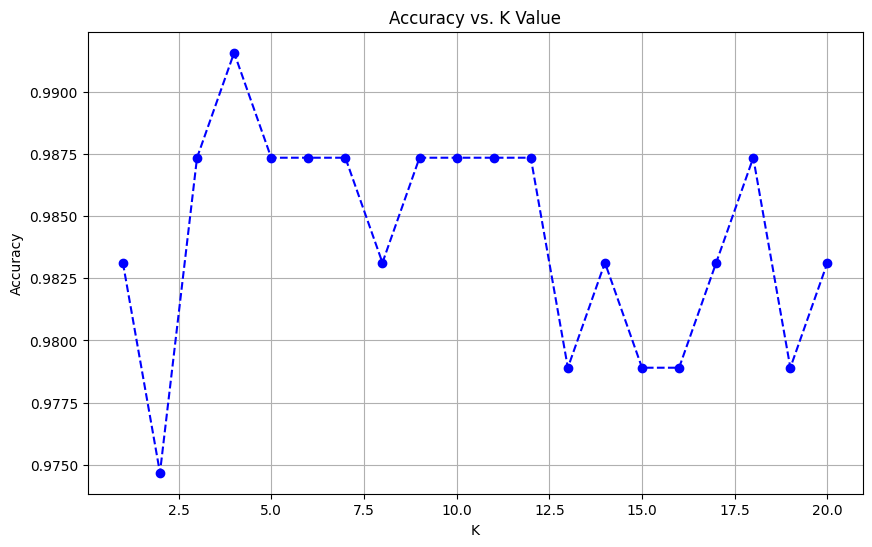

최적의 K값은 4입니다.


In [9]:
k_range = range(1, 21)
accuracies = []

for k in k_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    accuracies.append(pipe.score(X_test, y_test))

# 결과 시각화
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='dashed', color='blue')
plt.title('Accuracy vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

best_k = k_range[accuracies.index(max(accuracies))]
print(f"최적의 K값은 {best_k}입니다.")

In [10]:
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])
best_model.fit(X_train, y_train)

# 예측값 생성
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print("\n[ 성능 비교 결과 ]")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

print("\n[ 상세 분류 리포트 ]")
print(classification_report(y_test, y_test_pred))


[ 성능 비교 결과 ]
Train Accuracy: 0.9968
Test Accuracy: 0.9916

[ 상세 분류 리포트 ]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       155
           1       0.99      0.99      0.99        82

    accuracy                           0.99       237
   macro avg       0.99      0.99      0.99       237
weighted avg       0.99      0.99      0.99       237

